# Prefix-Conditioned Humor Quantile Prediction

This notebook follows the spirit of Gagne and Dayan, **The Inner Sentiments of a Thought** ([arXiv:2307.01784](https://arxiv.org/abs/2307.01784)): train quantile predictors of a final affective score from transformer hidden states of growing sentence prefixes.

Here the final target is the end-of-sentence humor `score` from `datasets/200k_short_texts_for_humor_detection_scored.csv`. For every text prefix, the target is the full sentence's final score. This is a Monte Carlo / TD(1)-style target: each prefix learns to predict the distribution of possible final humor scores from the partial text seen so far.

## 1. Imports and M2 Pro Setup

The notebook uses PyTorch MPS when your local Apple Silicon runtime exposes it. If MPS is unavailable, it falls back to CPU. On your previous macOS 13.3 runtime, PyTorch reported `MPS built: True` but `MPS available: False`, so CPU fallback may be used until macOS is updated.

In [49]:
from pathlib import Path
import json
import os
import platform
import re
import warnings

os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")
os.environ.setdefault("MPLCONFIGDIR", str(Path(".matplotlib-cache").resolve()))

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.auto import tqdm
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")

DATA_PATH = Path("datasets/200k_short_texts_for_humor_detection_scored.csv")
OUTPUT_DIR = Path("outputs/humor_prefix_quantile_td1")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

HF_MODEL_NAME = "iamahmadyasin/humor-distilbert"
TEXT_COLUMN = "text"
SCORE_COLUMN = "score"
RANDOM_STATE = 42

# Hugging Face model-card examples for this model use max_length=128.
MAX_LENGTH = 128

# Feature extraction over growing prefixes can be large: roughly sum(number_of_words) rows.
# None means use every row and every whitespace-word prefix from the scored dataset.
MAX_ROWS = None
MAX_PREFIXES_PER_TEXT = None

# Batches for DistilBERT prefix encoding and quantile-network training.
PREFIX_EXTRACTION_BATCH_SIZE = None
QUANTILE_TRAIN_BATCH_SIZE = None

# One epoch requested.
EPOCHS = 5
LEARNING_RATE = 1e-3
HUBER_KAPPA = 1.0
EVAL_EVERY_STEPS = 100
TEST_TRAJECTORY_PREFIXES = 50000
FINAL_EVAL_MAX_PREFIXES = 200000

# Cache extracted prefix hidden states. Set True after changing feature-extraction settings.
FORCE_RECOMPUTE_PREFIX_FEATURES = False

USE_FLOAT16_ON_MPS = True
FEATURE_STORAGE_DTYPE = np.float16

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

if PREFIX_EXTRACTION_BATCH_SIZE is None:
    PREFIX_EXTRACTION_BATCH_SIZE = 128 if DEVICE.type in {"cuda", "mps"} else 32
if QUANTILE_TRAIN_BATCH_SIZE is None:
    QUANTILE_TRAIN_BATCH_SIZE = 2048 if DEVICE.type in {"cuda", "mps"} else 512

if hasattr(torch, "set_float32_matmul_precision"):
    torch.set_float32_matmul_precision("high")

mps_backend = getattr(torch.backends, "mps", None)
print("Python:", platform.python_version())
print("macOS:", platform.mac_ver())
print("Machine:", platform.machine())
print("PyTorch:", torch.__version__)
if mps_backend is not None:
    print("MPS built:", mps_backend.is_built())
    print("MPS available:", mps_backend.is_available())
print("Selected device:", DEVICE)
print("Prefix extraction batch size:", PREFIX_EXTRACTION_BATCH_SIZE)
print("Quantile training batch size:", QUANTILE_TRAIN_BATCH_SIZE)

Python: 3.12.13
macOS: ('26.5.2', ('', '', ''), 'arm64')
Machine: arm64
PyTorch: 2.11.0
MPS built: True
MPS available: True
Selected device: mps
Prefix extraction batch size: 128
Quantile training batch size: 2048


## 2. Load Scored Humor Dataset

The split is by complete text, not prefix, so prefixes from the same sentence cannot leak across train/validation/test.

In [ ]:
df = pd.read_csv(DATA_PATH)

if SCORE_COLUMN not in df.columns and "log-score" in df.columns:
    SCORE_COLUMN = "log-score"
if TEXT_COLUMN not in df.columns:
    string_cols = [col for col in df.columns if df[col].dtype == "object" or str(df[col].dtype).startswith("string")]
    if not string_cols:
        raise ValueError("Could not find a text column.")
    TEXT_COLUMN = string_cols[0]

df = df[[TEXT_COLUMN, SCORE_COLUMN] + (["humor"] if "humor" in df.columns else [])].copy()
df[TEXT_COLUMN] = df[TEXT_COLUMN].astype("string")
df[SCORE_COLUMN] = pd.to_numeric(df[SCORE_COLUMN], errors="coerce")
df = df.dropna(subset=[TEXT_COLUMN, SCORE_COLUMN])
df[TEXT_COLUMN] = df[TEXT_COLUMN].str.strip()
df = df[df[TEXT_COLUMN] != ""].reset_index(drop=True)
if MAX_ROWS is not None:
    df = df.sample(n=min(MAX_ROWS, len(df)), random_state=RANDOM_STATE).reset_index(drop=True)

df["row_id"] = np.arange(len(df), dtype=np.int32)
WORD_RE = re.compile(r"\S+")
df["words"] = df[TEXT_COLUMN].map(lambda text: WORD_RE.findall(str(text)))
if MAX_PREFIXES_PER_TEXT is not None:
    df["words"] = df["words"].map(lambda words: words[:MAX_PREFIXES_PER_TEXT])
df["prefix_count"] = df["words"].map(len).astype(np.int32)
df = df[df["prefix_count"] > 0].reset_index(drop=True)
df["row_id"] = np.arange(len(df), dtype=np.int32)

print("Rows:", len(df))
print("Text column:", TEXT_COLUMN)
print("Score column:", SCORE_COLUMN)
print("Total prefixes:", int(df["prefix_count"].sum()))
display(df[["row_id", TEXT_COLUMN, SCORE_COLUMN, "prefix_count"]].head())
display(df[[SCORE_COLUMN, "prefix_count"]].describe())

Rows: 200000
Text column: text
Score column: score
Total prefixes: 2396665
Max prefixes per text: 18


,row_id,text,score,prefix_count
0,0,"Joe biden rules out 2020 bid: 'guys, i'm not r...",0.679970,10
1,1,Watch: darvish gave hitter whiplash with slow ...,0.421646,8
2,2,What do you call a turtle without its shell? d...,0.895106,10
3,3,5 reasons the 2016 election feels so personal,1.223488,8
4,4,"Pasco police shot mexican migrant from behind,...",0.837635,10


,score,prefix_count
count,200000.000000,200000.000000
mean,1.099934,11.983325
std,0.740772,2.758912
min,0.013325,8.000000
25%,0.615355,10.000000
50%,0.875954,12.000000
75%,1.326818,14.000000
max,7.856147,18.000000


## 3. Train / Validation / Test Split

In [3]:
row_indices = np.arange(len(df))

if "humor" in df.columns and df["humor"].nunique() > 1:
    stratify_labels = df["humor"].astype(str)
else:
    stratify_labels = pd.qcut(df[SCORE_COLUMN], q=10, duplicates="drop").astype(str)

train_rows, temp_rows = train_test_split(
    row_indices,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=stratify_labels,
)
temp_stratify = stratify_labels.iloc[temp_rows]
val_rows, test_rows = train_test_split(
    temp_rows,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=temp_stratify,
)

SPLIT_TO_ID = {"train": 0, "val": 1, "test": 2}
ID_TO_SPLIT = {value: key for key, value in SPLIT_TO_ID.items()}
row_split_ids = np.empty(len(df), dtype=np.int8)
row_split_ids[train_rows] = SPLIT_TO_ID["train"]
row_split_ids[val_rows] = SPLIT_TO_ID["val"]
row_split_ids[test_rows] = SPLIT_TO_ID["test"]
df["split"] = [ID_TO_SPLIT[int(split_id)] for split_id in row_split_ids]

split_summary = df.groupby("split").agg(rows=("row_id", "count"), prefixes=("prefix_count", "sum"), mean_score=(SCORE_COLUMN, "mean"))
display(split_summary)

,rows,prefixes,mean_score
split,,,
test,20000,239954,1.088894
train,160000,1917454,1.101433
val,20000,239257,1.098985


## 4. Load `humor-distilbert` and Extract Prefix Features

For each growing prefix, we extract the final-layer `[CLS]` hidden state from `iamahmadyasin/humor-distilbert`. The memory-mapped feature cache can be large because it contains one 768-dimensional vector per prefix.

In [4]:
tokenizer = AutoTokenizer.from_pretrained(HF_MODEL_NAME)
encoder = AutoModelForSequenceClassification.from_pretrained(HF_MODEL_NAME, output_hidden_states=True)

ENCODER_DTYPE = torch.float16 if DEVICE.type == "mps" and USE_FLOAT16_ON_MPS else torch.float32
encoder.to(device=DEVICE, dtype=ENCODER_DTYPE)
encoder.eval()

HIDDEN_SIZE = getattr(encoder.config, "hidden_size", None) or getattr(encoder.config, "dim")
print("Encoder:", HF_MODEL_NAME)
print("Encoder dtype:", ENCODER_DTYPE)
print("Hidden size:", HIDDEN_SIZE)

def move_encoder(device, dtype):
    global DEVICE, ENCODER_DTYPE, encoder, PREFIX_EXTRACTION_BATCH_SIZE
    DEVICE = torch.device(device)
    ENCODER_DTYPE = dtype
    encoder.to(device=DEVICE, dtype=ENCODER_DTYPE)
    encoder.eval()
    if DEVICE.type == "mps":
        torch.mps.empty_cache()
    else:
        PREFIX_EXTRACTION_BATCH_SIZE = min(PREFIX_EXTRACTION_BATCH_SIZE, 32)
    print(f"Encoder runtime now using device={DEVICE}, dtype={ENCODER_DTYPE}")


def encode_prefix_batch_once(prefix_texts):
    encoded = tokenizer(
        list(prefix_texts),
        padding=True,
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors="pt",
    )
    encoded = {key: value.to(DEVICE, non_blocking=True) for key, value in encoded.items()}
    with torch.inference_mode():
        outputs = encoder(**encoded, output_hidden_states=True, return_dict=True)
    return outputs.hidden_states[-1][:, 0, :].detach().cpu().float().numpy()


def encode_prefix_batch(prefix_texts):
    try:
        return encode_prefix_batch_once(prefix_texts)
    except RuntimeError as err:
        message = str(err)
        if DEVICE.type == "mps" and ENCODER_DTYPE == torch.float16:
            print("MPS float16 failed; retrying encoder on MPS float32. Original error:")
            print(message[:600])
            move_encoder("mps", torch.float32)
            return encode_prefix_batch_once(prefix_texts)
        if DEVICE.type == "mps":
            print("MPS failed; retrying encoder on CPU float32. Original error:")
            print(message[:600])
            move_encoder("cpu", torch.float32)
            return encode_prefix_batch_once(prefix_texts)
        raise

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Encoder: iamahmadyasin/humor-distilbert
Encoder dtype: torch.float16
Hidden size: 768


In [5]:
total_prefixes = int(df["prefix_count"].sum())
features_path = OUTPUT_DIR / "prefix_final_layer_cls_float16.dat"
prefix_row_ids_path = OUTPUT_DIR / "prefix_row_ids.npy"
prefix_word_counts_path = OUTPUT_DIR / "prefix_word_counts.npy"
prefix_targets_path = OUTPUT_DIR / "prefix_targets.npy"
prefix_split_ids_path = OUTPUT_DIR / "prefix_split_ids.npy"
feature_metadata_path = OUTPUT_DIR / "prefix_feature_metadata.json"

feature_metadata = {
    "data_path": str(DATA_PATH),
    "data_size_bytes": DATA_PATH.stat().st_size,
    "rows": int(len(df)),
    "total_prefixes": int(total_prefixes),
    "text_column": TEXT_COLUMN,
    "score_column": SCORE_COLUMN,
    "model": HF_MODEL_NAME,
    "max_length": MAX_LENGTH,
    "max_rows": MAX_ROWS,
    "max_prefixes_per_text": MAX_PREFIXES_PER_TEXT,
    "hidden_size": int(HIDDEN_SIZE),
    "feature_dtype": "float16",
    "split_random_state": RANDOM_STATE,
}

def feature_cache_valid():
    if FORCE_RECOMPUTE_PREFIX_FEATURES:
        return False
    required = [features_path, prefix_row_ids_path, prefix_word_counts_path, prefix_targets_path, prefix_split_ids_path, feature_metadata_path]
    if not all(path.exists() for path in required):
        return False
    with feature_metadata_path.open() as f:
        return json.load(f) == feature_metadata


def flush_prefix_batch(prefix_texts, prefix_positions, feature_memmap, progress):
    if not prefix_texts:
        return
    vectors = encode_prefix_batch(prefix_texts)
    feature_memmap[np.array(prefix_positions, dtype=np.int64)] = vectors.astype(FEATURE_STORAGE_DTYPE)
    progress.update(len(prefix_texts))


estimated_feature_gb = total_prefixes * HIDDEN_SIZE * np.dtype(FEATURE_STORAGE_DTYPE).itemsize / 1e9
print(f"Estimated prefix feature cache size: {estimated_feature_gb:.2f} GB")

if feature_cache_valid():
    print("Loading cached prefix features and metadata arrays.")
else:
    print(f"Extracting {total_prefixes:,} prefix features. This may take a while.")
    prefix_features_write = np.memmap(features_path, dtype=FEATURE_STORAGE_DTYPE, mode="w+", shape=(total_prefixes, HIDDEN_SIZE))
    prefix_row_ids = np.empty(total_prefixes, dtype=np.int32)
    prefix_word_counts = np.empty(total_prefixes, dtype=np.int16)
    prefix_targets = np.empty(total_prefixes, dtype=np.float32)
    prefix_split_ids = np.empty(total_prefixes, dtype=np.int8)

    cursor = 0
    batch_texts = []
    batch_positions = []
    progress = tqdm(total=total_prefixes, desc="Encoding prefixes")

    for row in df.itertuples(index=False):
        row_id = int(row.row_id)
        words = getattr(row, "words")
        target = float(getattr(row, SCORE_COLUMN.replace("-", "_"), df.loc[row_id, SCORE_COLUMN]))
        split_id = int(row_split_ids[row_id])
        prefix_words = []
        for prefix_len, word in enumerate(words, start=1):
            prefix_words.append(word)
            prefix_text = " ".join(prefix_words)
            prefix_row_ids[cursor] = row_id
            prefix_word_counts[cursor] = prefix_len
            prefix_targets[cursor] = target
            prefix_split_ids[cursor] = split_id
            batch_texts.append(prefix_text)
            batch_positions.append(cursor)
            cursor += 1

            if len(batch_texts) >= PREFIX_EXTRACTION_BATCH_SIZE:
                flush_prefix_batch(batch_texts, batch_positions, prefix_features_write, progress)
                batch_texts.clear()
                batch_positions.clear()

    flush_prefix_batch(batch_texts, batch_positions, prefix_features_write, progress)
    progress.close()
    prefix_features_write.flush()
    del prefix_features_write

    np.save(prefix_row_ids_path, prefix_row_ids)
    np.save(prefix_word_counts_path, prefix_word_counts)
    np.save(prefix_targets_path, prefix_targets)
    np.save(prefix_split_ids_path, prefix_split_ids)
    with feature_metadata_path.open("w") as f:
        json.dump(feature_metadata, f, indent=2)

prefix_features = np.memmap(features_path, dtype=FEATURE_STORAGE_DTYPE, mode="r", shape=(total_prefixes, HIDDEN_SIZE))
prefix_row_ids = np.load(prefix_row_ids_path)
prefix_word_counts = np.load(prefix_word_counts_path)
prefix_targets = np.load(prefix_targets_path)
prefix_split_ids = np.load(prefix_split_ids_path)

print("Feature matrix:", prefix_features.shape, prefix_features.dtype)
print("Prefix targets:", prefix_targets.shape, prefix_targets.dtype)

Estimated prefix feature cache size: 3.68 GB
Extracting 2,396,665 prefix features. This may take a while.


Encoding prefixes:   0%|          | 0/2396665 [00:00<?, ?it/s]

Feature matrix: (2396665, 768) float16
Prefix targets: (2396665,) float32


## 5. Prepare Feature Normalization and PyTorch Datasets

In [6]:
train_prefix_indices = np.flatnonzero(prefix_split_ids == SPLIT_TO_ID["train"])
val_prefix_indices = np.flatnonzero(prefix_split_ids == SPLIT_TO_ID["val"])
test_prefix_indices = np.flatnonzero(prefix_split_ids == SPLIT_TO_ID["test"])

print("Train prefixes:", len(train_prefix_indices))
print("Val prefixes:", len(val_prefix_indices))
print("Test prefixes:", len(test_prefix_indices))

normalizer_path = OUTPUT_DIR / "feature_normalizer.npz"

def compute_feature_normalizer(indices, batch_size=50000):
    count = 0
    sum_x = np.zeros(HIDDEN_SIZE, dtype=np.float64)
    sum_x2 = np.zeros(HIDDEN_SIZE, dtype=np.float64)
    for start in tqdm(range(0, len(indices), batch_size), desc="Computing feature normalization"):
        batch_idx = indices[start : start + batch_size]
        x = np.asarray(prefix_features[batch_idx], dtype=np.float32)
        sum_x += x.sum(axis=0)
        sum_x2 += np.square(x, dtype=np.float32).sum(axis=0)
        count += x.shape[0]
    mean = (sum_x / count).astype(np.float32)
    var = (sum_x2 / count) - np.square(mean.astype(np.float64))
    std = np.sqrt(np.maximum(var, 1e-6)).astype(np.float32)
    return mean, std

if normalizer_path.exists():
    data = np.load(normalizer_path)
    feature_mean = data["mean"].astype(np.float32)
    feature_std = data["std"].astype(np.float32)
else:
    feature_mean, feature_std = compute_feature_normalizer(train_prefix_indices)
    np.savez(normalizer_path, mean=feature_mean, std=feature_std)

class PrefixFeatureDataset(Dataset):
    def __init__(self, indices, features, targets, mean, std):
        self.indices = np.asarray(indices, dtype=np.int64)
        self.features = features
        self.targets = targets
        self.mean = mean
        self.std = std

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, item):
        idx = self.indices[item]
        x = np.asarray(self.features[idx], dtype=np.float32)
        x = (x - self.mean) / self.std
        y = np.float32(self.targets[idx])
        return torch.from_numpy(x), torch.tensor(y, dtype=torch.float32)


rng = np.random.default_rng(RANDOM_STATE)
test_trajectory_indices = rng.choice(test_prefix_indices, size=min(TEST_TRAJECTORY_PREFIXES, len(test_prefix_indices)), replace=False)

train_dataset = PrefixFeatureDataset(train_prefix_indices, prefix_features, prefix_targets, feature_mean, feature_std)
val_dataset = PrefixFeatureDataset(val_prefix_indices, prefix_features, prefix_targets, feature_mean, feature_std)
test_dataset = PrefixFeatureDataset(test_prefix_indices, prefix_features, prefix_targets, feature_mean, feature_std)
test_trajectory_dataset = PrefixFeatureDataset(test_trajectory_indices, prefix_features, prefix_targets, feature_mean, feature_std)

train_loader = DataLoader(train_dataset, batch_size=QUANTILE_TRAIN_BATCH_SIZE, shuffle=True, num_workers=0)
test_trajectory_loader = DataLoader(test_trajectory_dataset, batch_size=QUANTILE_TRAIN_BATCH_SIZE, shuffle=False, num_workers=0)

Train prefixes: 1917454
Val prefixes: 239257
Test prefixes: 239954


Computing feature normalization:   0%|          | 0/39 [00:00<?, ?it/s]

## 6. Quantile MLP and Huber Quantile Loss

The network is exactly one hidden layer with 100 hidden units and 10 outputs for the 5%, 15%, ..., 95% quantiles.

In [7]:
quantiles_np = np.arange(0.05, 1.00, 0.10, dtype=np.float32)
quantiles = torch.tensor(quantiles_np, dtype=torch.float32, device=DEVICE)

class QuantileMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=100, output_dim=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim),
        )

    def forward(self, x):
        return self.net(x)


def huber_quantile_loss(predictions, targets, taus, kappa=1.0):
    errors = targets.unsqueeze(1) - predictions
    abs_errors = errors.abs()
    huber = torch.where(abs_errors <= kappa, 0.5 * errors.pow(2), kappa * (abs_errors - 0.5 * kappa))
    weights = torch.abs(taus.view(1, -1) - (errors.detach() < 0).float())
    return (weights * huber).mean()


def quantile_mae(predictions, targets):
    # The requested grid is 5%, 15%, ..., 95%, so approximate the median
    # as the midpoint between the 45% and 55% outputs.
    median_pred = 0.5 * (predictions[:, 4] + predictions[:, 5])
    return torch.mean(torch.abs(median_pred - targets))


quantile_model = QuantileMLP(HIDDEN_SIZE, hidden_dim=100, output_dim=len(quantiles_np)).to(DEVICE)
optimizer = torch.optim.AdamW(quantile_model.parameters(), lr=LEARNING_RATE)
print(quantile_model)
print("Quantiles:", quantiles_np)

QuantileMLP(
  (net): Sequential(
    (0): Linear(in_features=768, out_features=100, bias=True)
    (1): ReLU()
    (2): Linear(in_features=100, out_features=10, bias=True)
  )
)
Quantiles: [0.05       0.15       0.25000003 0.35000002 0.45000005 0.5500001
 0.65000004 0.75000006 0.8500001  0.9500001 ]


## 7. Train for One Epoch and Track Train vs Test Performance

In [50]:
def evaluate_loader(loader, max_batches=None):
    quantile_model.eval()
    total_loss = 0.0
    total_mae = 0.0
    total_n = 0
    with torch.inference_mode():
        for batch_idx, (x, y) in enumerate(loader):
            if max_batches is not None and batch_idx >= max_batches:
                break
            x = x.to(DEVICE)
            y = y.to(DEVICE)
            preds = quantile_model(x)
            loss = huber_quantile_loss(preds, y, quantiles, HUBER_KAPPA)
            mae = quantile_mae(preds, y)
            batch_n = x.shape[0]
            total_loss += float(loss.detach().cpu()) * batch_n
            total_mae += float(mae.detach().cpu()) * batch_n
            total_n += batch_n
    return {"loss": total_loss / total_n, "median_mae": total_mae / total_n}


history = []
global_step = 0
recent_train_losses = []

for epoch in range(1, EPOCHS + 1):
    quantile_model.train()
    progress = tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS}")
    for x, y in progress:
        x = x.to(DEVICE)
        y = y.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        preds = quantile_model(x)
        loss = huber_quantile_loss(preds, y, quantiles, HUBER_KAPPA)
        loss.backward()
        optimizer.step()

        global_step += 1
        recent_train_losses.append(float(loss.detach().cpu()))
        progress.set_postfix(train_loss=recent_train_losses[-1])

        if global_step == 1 or global_step % EVAL_EVERY_STEPS == 0:
            train_loss = float(np.mean(recent_train_losses))
            recent_train_losses.clear()
            test_metrics = evaluate_loader(test_trajectory_loader)
            history.append(
                {
                    "epoch": epoch,
                    "step": global_step,
                    "train_loss": train_loss,
                    "test_loss": test_metrics["loss"],
                    "test_median_mae": test_metrics["median_mae"],
                }
            )
            quantile_model.train()

history_df = pd.DataFrame(history)
history_df.to_csv(OUTPUT_DIR / "training_trajectory.csv", index=False)
display(history_df.tail())

Epoch 1/5:   0%|          | 0/937 [00:00<?, ?it/s]

Epoch 2/5:   0%|          | 0/937 [00:00<?, ?it/s]

Epoch 3/5:   0%|          | 0/937 [00:00<?, ?it/s]

Epoch 4/5:   0%|          | 0/937 [00:00<?, ?it/s]

Epoch 5/5:   0%|          | 0/937 [00:00<?, ?it/s]

,epoch,step,train_loss,test_loss,test_median_mae
42,5,4200,0.046648,0.050659,0.361873
43,5,4300,0.047032,0.050543,0.359334
44,5,4400,0.046983,0.050599,0.361374
45,5,4500,0.047094,0.050584,0.360834
46,5,4600,0.046768,0.050600,0.361970


## 8. Final Validation/Test Evaluation

In [51]:
def maybe_subsample(indices, max_items, seed):
    if max_items is None or len(indices) <= max_items:
        return indices
    rng = np.random.default_rng(seed)
    return rng.choice(indices, size=max_items, replace=False)

final_train_eval_indices = maybe_subsample(train_prefix_indices, FINAL_EVAL_MAX_PREFIXES, RANDOM_STATE + 1)
final_val_eval_indices = maybe_subsample(val_prefix_indices, FINAL_EVAL_MAX_PREFIXES, RANDOM_STATE + 2)
final_test_eval_indices = maybe_subsample(test_prefix_indices, FINAL_EVAL_MAX_PREFIXES, RANDOM_STATE + 3)

final_train_loader = DataLoader(PrefixFeatureDataset(final_train_eval_indices, prefix_features, prefix_targets, feature_mean, feature_std), batch_size=QUANTILE_TRAIN_BATCH_SIZE, shuffle=False, num_workers=0)
final_val_loader = DataLoader(PrefixFeatureDataset(final_val_eval_indices, prefix_features, prefix_targets, feature_mean, feature_std), batch_size=QUANTILE_TRAIN_BATCH_SIZE, shuffle=False, num_workers=0)
final_test_loader = DataLoader(PrefixFeatureDataset(final_test_eval_indices, prefix_features, prefix_targets, feature_mean, feature_std), batch_size=QUANTILE_TRAIN_BATCH_SIZE, shuffle=False, num_workers=0)

final_metrics = pd.DataFrame(
    [
        {"split": "train", "prefixes_evaluated": len(final_train_eval_indices), **evaluate_loader(final_train_loader)},
        {"split": "val", "prefixes_evaluated": len(final_val_eval_indices), **evaluate_loader(final_val_loader)},
        {"split": "test", "prefixes_evaluated": len(final_test_eval_indices), **evaluate_loader(final_test_loader)},
    ]
)
final_metrics.to_csv(OUTPUT_DIR / "final_eval_metrics.csv", index=False)
display(final_metrics)

torch.save(
    {
        "model_state_dict": quantile_model.state_dict(),
        "feature_mean": feature_mean,
        "feature_std": feature_std,
        "quantiles": quantiles_np,
        "hidden_size": HIDDEN_SIZE,
        "hf_model_name": HF_MODEL_NAME,
        "score_column": SCORE_COLUMN,
    },
    OUTPUT_DIR / "quantile_mlp_td1.pt",
)

,split,prefixes_evaluated,loss,median_mae
0,train,200000,0.046652,0.347786
1,val,200000,0.052211,0.368168
2,test,200000,0.050580,0.363351


## 9. Plot Training Trajectory

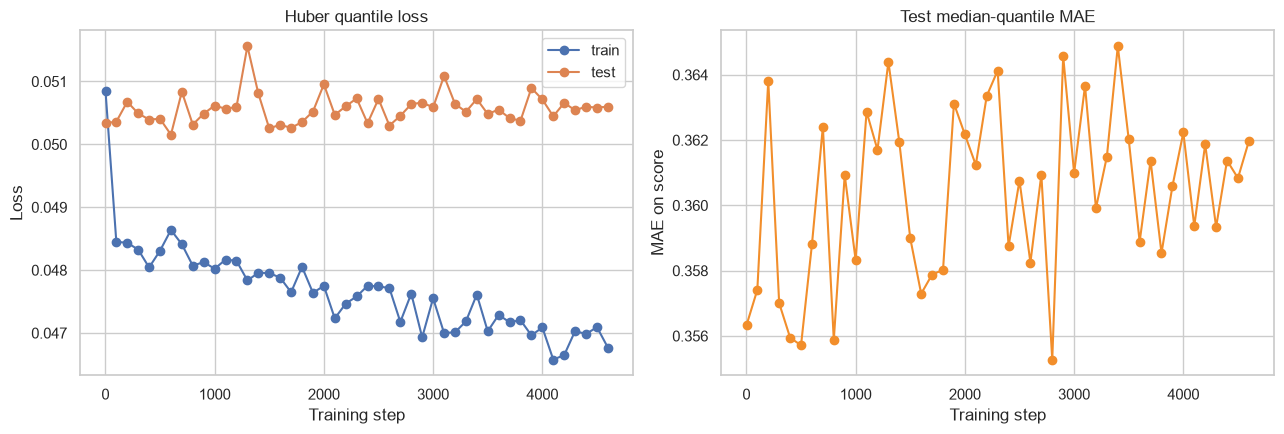

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(history_df["step"], history_df["train_loss"], marker="o", label="train")
axes[0].plot(history_df["step"], history_df["test_loss"], marker="o", label="test")
axes[0].set_title("Huber quantile loss")
axes[0].set_xlabel("Training step")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(history_df["step"], history_df["test_median_mae"], marker="o", color="#f28e2b")
axes[1].set_title("Test median-quantile MAE")
axes[1].set_xlabel("Training step")
axes[1].set_ylabel("MAE on score")

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "training_vs_test_trajectory.png", dpi=180, bbox_inches="tight")
plt.show()

## 10. Inspect Prefix-Conditioned Quantiles for One Text

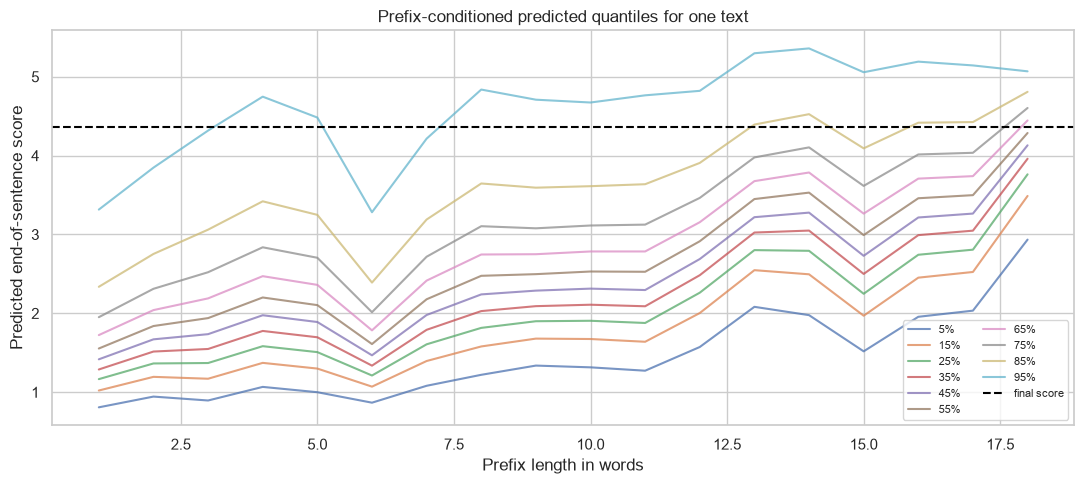

Example text:
I just found out a distant relative of mine has eaten three people. it's a lot to digest
Final score: 4.3627834


In [57]:
def predict_quantiles_for_prefix_indices(prefix_indices):
    dataset = PrefixFeatureDataset(prefix_indices, prefix_features, prefix_targets, feature_mean, feature_std)
    loader = DataLoader(dataset, batch_size=QUANTILE_TRAIN_BATCH_SIZE, shuffle=False, num_workers=0)
    preds = []
    quantile_model.eval()
    with torch.inference_mode():
        for x, _ in loader:
            preds.append(quantile_model(x.to(DEVICE)).detach().cpu().numpy())
    return np.concatenate(preds, axis=0)


example_row_id = int(df.sort_values("prefix_count", ascending=False)["row_id"].iloc[7])
example_prefix_indices = np.flatnonzero(prefix_row_ids == example_row_id)
example_quantiles = predict_quantiles_for_prefix_indices(example_prefix_indices)
example_prefix_counts = prefix_word_counts[example_prefix_indices]
example_target = float(df.loc[example_row_id, SCORE_COLUMN])

fig, ax = plt.subplots(figsize=(11, 5))
for quantile_idx, tau in enumerate(quantiles_np):
    ax.plot(example_prefix_counts, example_quantiles[:, quantile_idx], alpha=0.75, label=f"{int(tau * 100)}%")
ax.axhline(example_target, color="black", linestyle="--", linewidth=1.5, label="final score")
ax.set_title("Prefix-conditioned predicted quantiles for one text")
ax.set_xlabel("Prefix length in words")
ax.set_ylabel("Predicted end-of-sentence score")
ax.legend(ncol=2, fontsize=8)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "example_prefix_quantile_trajectory.png", dpi=180, bbox_inches="tight")
plt.show()

print("Example text:")
print(df.loc[example_row_id, TEXT_COLUMN])
print("Final score:", example_target)

## Outputs

Artifacts are saved under `outputs/humor_prefix_quantile_td1/`:

- `prefix_final_layer_cls_float16.dat`: memory-mapped final-layer prefix features
- `prefix_row_ids.npy`, `prefix_word_counts.npy`, `prefix_targets.npy`, `prefix_split_ids.npy`: prefix metadata arrays
- `quantile_mlp_td1.pt`: trained one-hidden-layer quantile MLP
- `training_trajectory.csv` and `training_vs_test_trajectory.png`: train/test trajectory
- `final_eval_metrics.csv`: train/validation/test metrics
- `example_prefix_quantile_trajectory.png`: example predicted quantile path